# Telco Customer Churn Prediction

This project analyzes the Telco Customer Churn dataset and builds multiple ML models to predict if a customer will churn or not.

## Objectives
- Perform exploratory data analysis (EDA)
- Clean and preprocess the dataset
- Train multiple machine learning models
- Compare model performance using ROC-AUC
- Identify important features affecting churn

## 1. Import Libraries

In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [65]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,roc_auc_score

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB

from xgboost import XGBClassifier

## 2. Load Dataset

In [2]:
data=pd.read_csv("/content/Telco-Customer-Churn.csv")

## 3. Initial Data Exploration

In [3]:
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
data.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [6]:
data.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## Business Hypotheses

Before exploring the data, we formulate a few hypotheses based on common patterns in customer retention:

1. Customers with **month-to-month contracts** are more likely to churn.
2. **Senior citizens** are more likely to churn.
3. Customers with **lower tenure** are more likely to leave the service.

These hypotheses will be tested during the exploratory data analysis phase.


## 4. Data Cleaning

In [10]:
data.drop(data[data['TotalCharges']==' '].index,axis=0,inplace=True)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


## 5. Churn Distribution Analysis

In [19]:
count=data['Churn'].value_counts()

([<matplotlib.patches.Wedge at 0x7e83bcbafad0>,
 [Text(-0.7393678155529122, 0.8144539479458093, 'No'),
  Text(0.7393680809356543, -0.8144537070291521, 'Yes')],
 [Text(-0.40329153575613386, 0.4442476079704414, '73.5%'),
  Text(0.40329168051035685, -0.44424747656135566, '26.5%')])

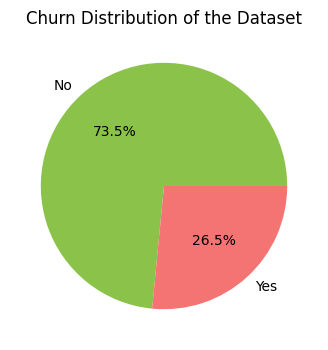

In [63]:
plt.figure(figsize=(4,4))
plt.title("Churn Distribution of the Dataset")
plt.pie(count,labels=count.index,autopct='%1.1f%%',colors=['#8bc34a','#f47373'])

## 6. Exploratory Data Analysis (EDA)

In [26]:
data['TotalCharges']=pd.to_numeric(data['TotalCharges'],errors='coerce')

In [27]:
print(data.isnull().sum().sort_values(ascending=False))

TotalCharges        11
gender               0
SeniorCitizen        0
Partner              0
customerID           0
Dependents           0
tenure               0
MultipleLines        0
PhoneService         0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
InternetService      0
TechSupport          0
StreamingTV          0
Contract             0
StreamingMovies      0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
Churn                0
dtype: int64


In [28]:
data.dropna(inplace=True)

In [29]:
data=data.drop(columns='customerID')

In [30]:
data.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441
std,0.368844,24.545260,30.085974,2266.771362
min,0.000000,1.000000,18.250000,18.800000
25%,0.000000,9.000000,35.587500,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.862500,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


## 7. Feature Encoding and Preprocessing

In [36]:
for col in data.columns:
    if data[col].dtype != 'int64' and data[col].dtype != 'float64':
        print(f'{col} : {data[col].unique()}')

gender : ['Female' 'Male']
Partner : ['Yes' 'No']
Dependents : ['No' 'Yes']
PhoneService : ['No' 'Yes']
MultipleLines : ['No phone service' 'No' 'Yes']
InternetService : ['DSL' 'Fiber optic' 'No']
OnlineSecurity : ['No' 'Yes' 'No internet service']
OnlineBackup : ['Yes' 'No' 'No internet service']
DeviceProtection : ['No' 'Yes' 'No internet service']
TechSupport : ['No' 'Yes' 'No internet service']
StreamingTV : ['No' 'Yes' 'No internet service']
StreamingMovies : ['No' 'Yes' 'No internet service']
Contract : ['Month-to-month' 'One year' 'Two year']
PaperlessBilling : ['Yes' 'No']
PaymentMethod : ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
Churn : ['No' 'Yes']


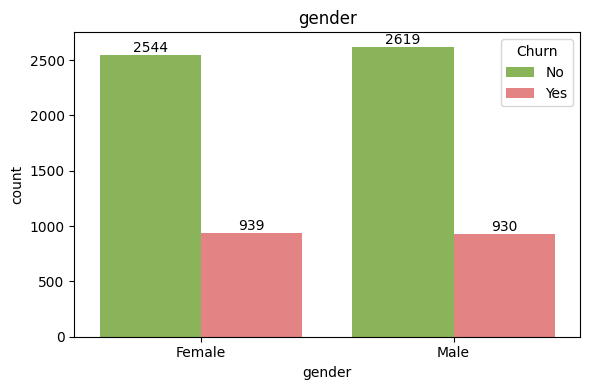

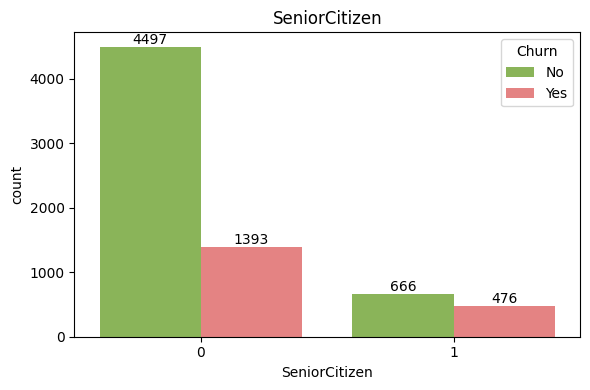

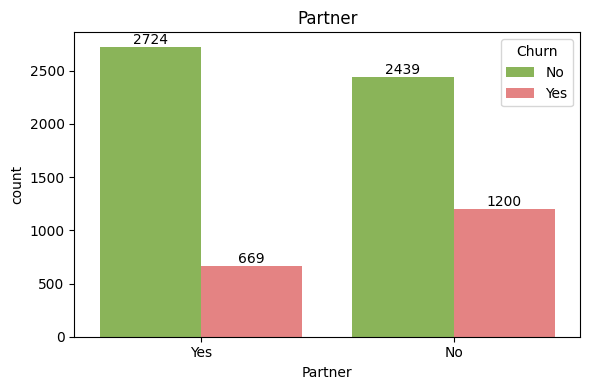

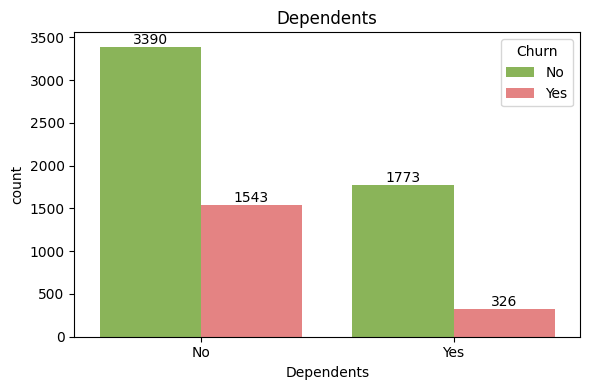

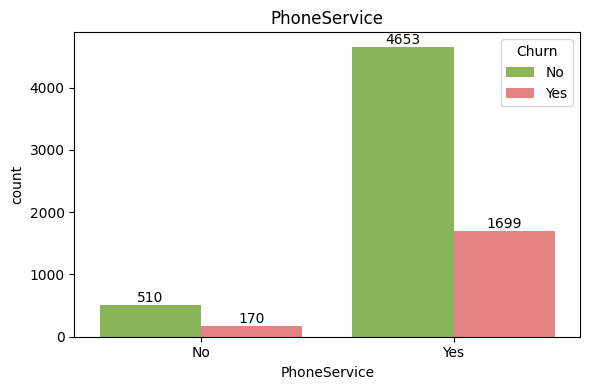

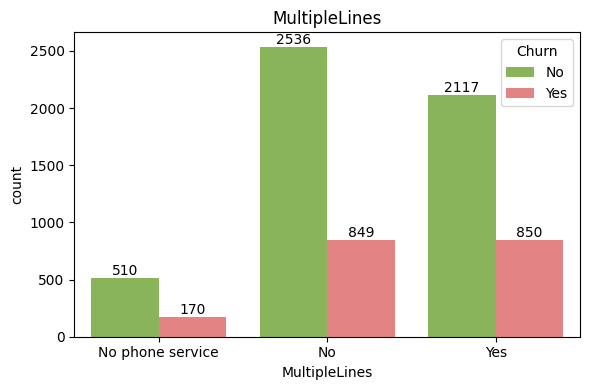

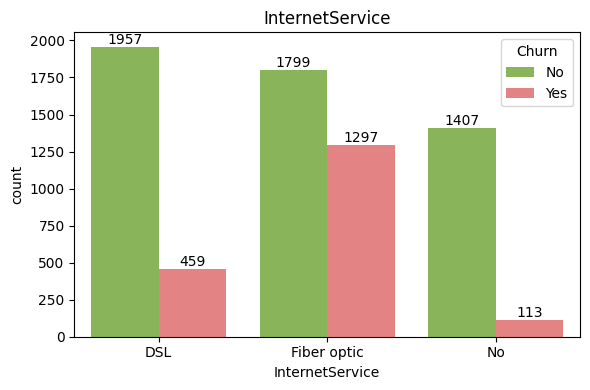

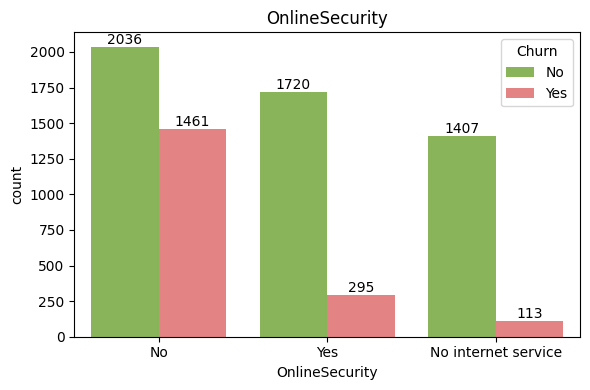

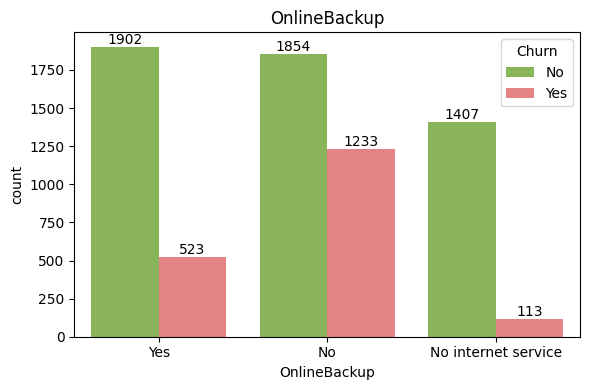

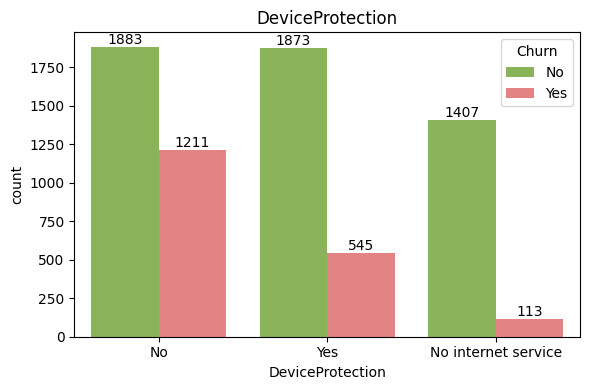

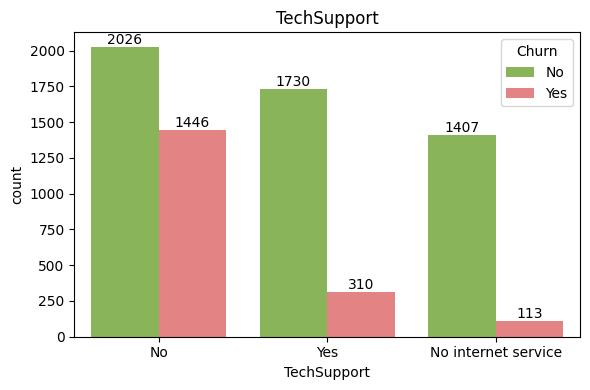

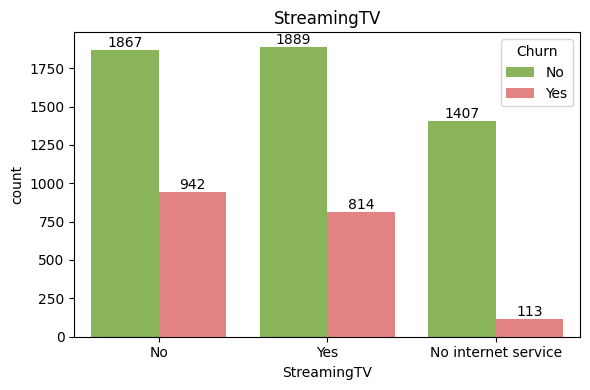

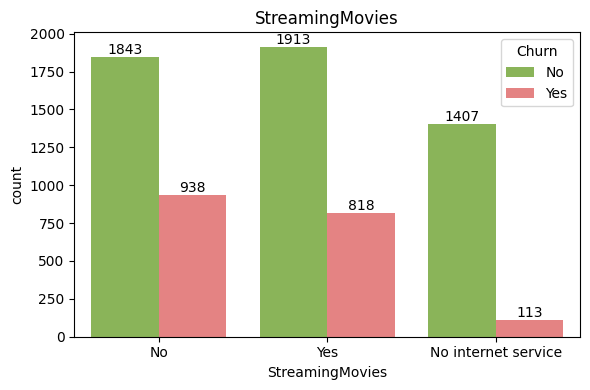

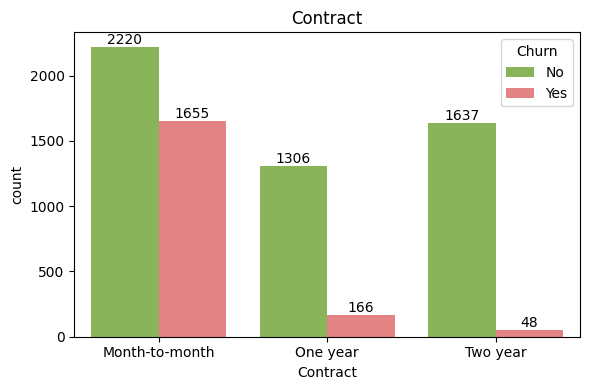

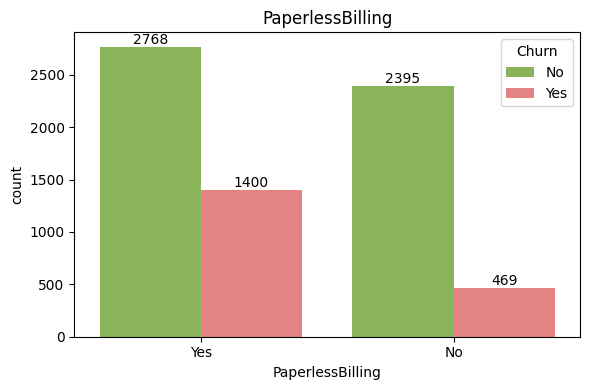

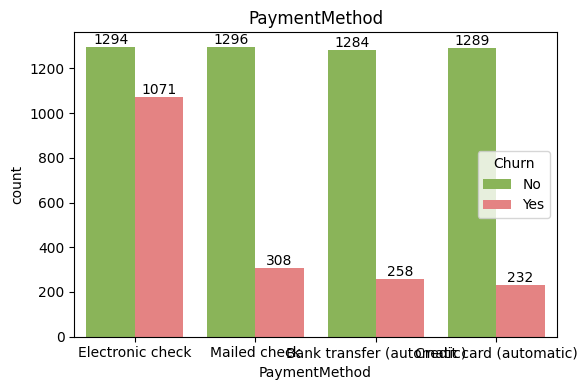

In [38]:
colors = {'Yes': '#f47373', 'No': '#8bc34a'}

for i, predictor in enumerate(data.drop(columns=['Churn', 'TotalCharges', 'MonthlyCharges', 'tenure'])):
    plt.figure(i, figsize=(6, 4))
    ax = sns.countplot(data=data, x=predictor, hue='Churn', palette=colors)
    plt.title(predictor)


    for container in ax.containers:
        ax.bar_label(container)

    plt.tight_layout()
    plt.show()

### Hypothesis 1: Customers with Month-to-Month Contracts Are More Likely to Churn
**Observation**

Customers with **month-to-month contracts show a significantly higher churn rate** compared to customers with one-year or two-year contracts.

**Conclusion**

✔ Hypothesis supported: Customers with flexible contracts are more likely to leave the service.

### Hypothesis 2: Senior Citizens Are More Likely to Churn

**Observation**

The churn rate among **senior citizens appears slightly higher** compared to non-senior customers.

However, the difference is **not extremely large**, suggesting that while age may influence churn, it is not the strongest factor.

**Conclusion**

⚠ Hypothesis partially supported: Senior citizens show somewhat higher churn, but the effect is moderate.

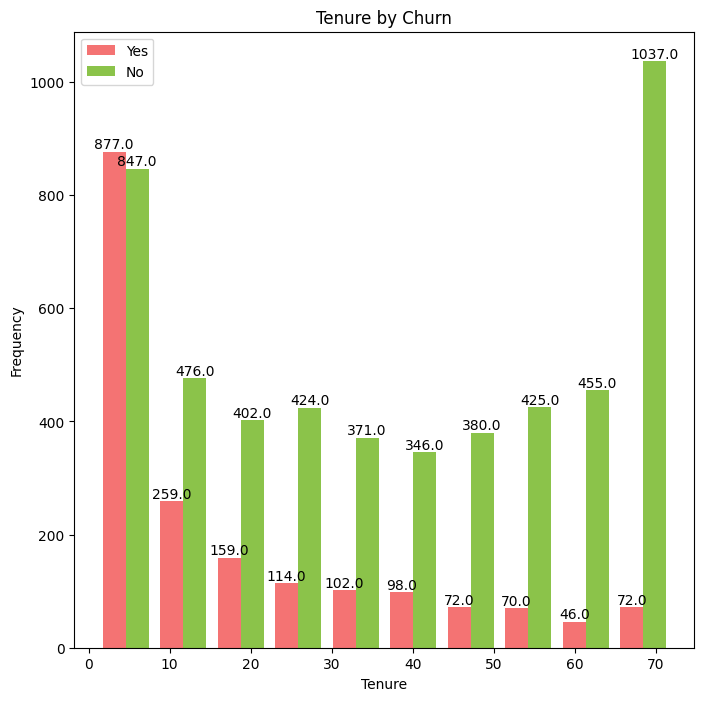

In [44]:
churned=data[data['Churn']=='Yes']
not_churned=data[data['Churn']=='No']

plt.figure(figsize=(8,8))
plt.hist([churned['tenure'],not_churned['tenure']],color=['#f47373','#8bc34a'],label=['Yes','No'])
plt.title('Tenure by Churn')
plt.xlabel('Tenure')
plt.ylabel('Frequency')
plt.legend()


for rect in plt.gca().patches:
    height = rect.get_height()
    plt.gca().text(rect.get_x() + rect.get_width() / 2, height, height, ha='center', va='bottom')

### Hypothesis 3: Customers With Lower Tenure Are More Likely to Churn

**Observation**

Customers with **lower tenure (newer customers)** exhibit much higher churn rates compared to long-term customers.

Customers who stay longer with the company are significantly less likely to churn.

**Conclusion**

✔ Hypothesis strongly supported: Newer customers are more likely to leave.

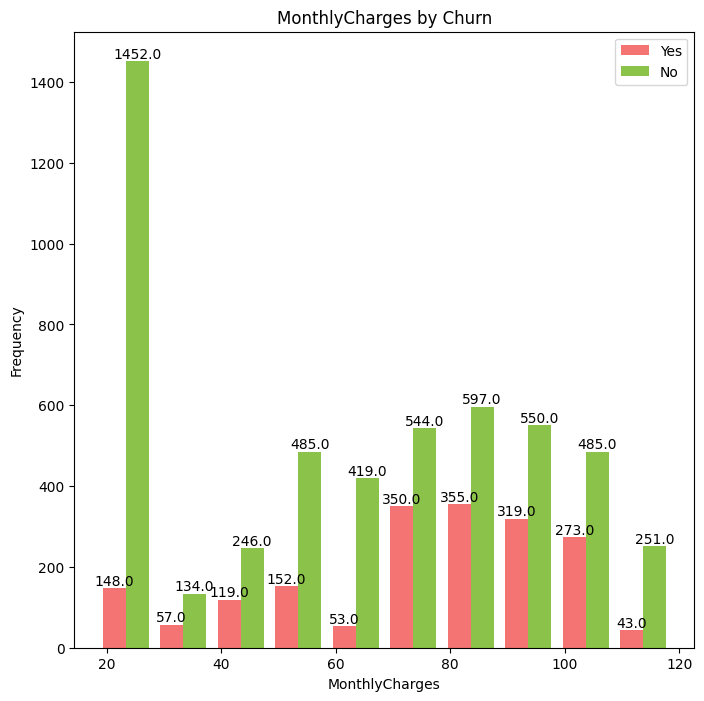

In [45]:
churned=data[data['Churn']=='Yes']
not_churned=data[data['Churn']=='No']

plt.figure(figsize=(8,8))
plt.hist([churned['MonthlyCharges'],not_churned['MonthlyCharges']],color=['#f47373','#8bc34a'],label=['Yes','No'])
plt.title('MonthlyCharges by Churn')
plt.xlabel('MonthlyCharges')
plt.ylabel('Frequency')
plt.legend()


for rect in plt.gca().patches:
    height = rect.get_height()
    plt.gca().text(rect.get_x() + rect.get_width() / 2, height, height, ha='center', va='bottom')

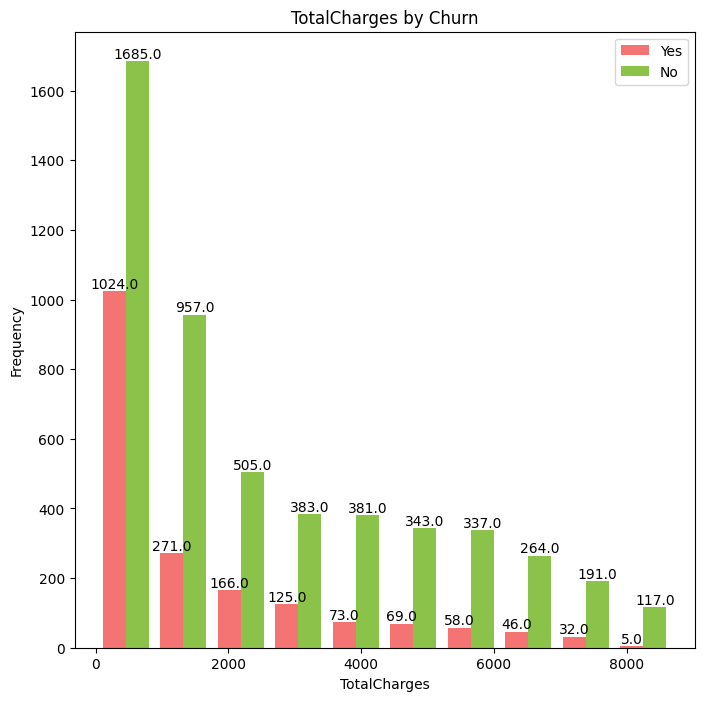

In [46]:
churned=data[data['Churn']=='Yes']
not_churned=data[data['Churn']=='No']

plt.figure(figsize=(8,8))
plt.hist([churned['TotalCharges'],not_churned['TotalCharges']],color=['#f47373','#8bc34a'],label=['Yes','No'])
plt.title('TotalCharges by Churn')
plt.xlabel('TotalCharges')
plt.ylabel('Frequency')
plt.legend()


for rect in plt.gca().patches:
    height = rect.get_height()
    plt.gca().text(rect.get_x() + rect.get_width() / 2, height, height, ha='center', va='bottom')

In [49]:
from sklearn.preprocessing import LabelEncoder,OneHotEncoder, StandardScaler
le=LabelEncoder()
data['Churn']=le.fit_transform(data['Churn'])

categorical_cols=data.select_dtypes(include='object').columns.tolist()
if 'Churn' in categorical_cols:
  categorical_cols.remove('Churn')

  data=pd.get_dummies(data,columns=categorical_cols,drop_first=True)
  numerical_cols=['tenure','MonthlyCharges','TotalCharges']

  scaler=StandardScaler()
  data[numerical_cols]=scaler.fit_transform(data[numerical_cols])

## 8. Train-Test Split

In [51]:
X=data.drop('Churn',axis=1)
y=data['Churn']

from sklearn.model_selection import train_test_split
print('X shape: ',X.shape)
print('y shape: ',y.shape)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=42, stratify=y)

X shape:  (7032, 19)
y shape:  (7032,)


## 9. Machine Learning Models and Hyperparameter Tuning



In [66]:
categorical_cols = X_train.select_dtypes(include=['object']).columns
numeric_cols = X_train.select_dtypes(exclude=['object']).columns


preprocessor = ColumnTransformer(
    transformers=[
        ('num', MinMaxScaler(), numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)


model_scores = []

models = [

    ('Random Forest',
     RandomForestClassifier(random_state=42),
     {'model__n_estimators':[50,100,200],
      'model__max_depth':[None,10,20]}),

    ('Gradient Boosting',
     GradientBoostingClassifier(random_state=42),
     {'model__n_estimators':[50,100,200],
      'model__learning_rate':[0.05,0.1,0.5]}),

    ('Support Vector Machine',
     SVC(class_weight='balanced', probability=True),
     {'model__C':[0.1,1,10],
      'model__gamma':['scale','auto']}),

    ('Logistic Regression',
     LogisticRegression(class_weight='balanced', solver='liblinear'),
     {'model__C':[0.1,1,10],
      'model__penalty':['l1','l2']}),

    ('KNN',
     KNeighborsClassifier(),
     {'model__n_neighbors':[3,5,7],
      'model__weights':['uniform','distance']}),

    ('Decision Tree',
     DecisionTreeClassifier(random_state=42),
     {'model__max_depth':[None,10,20],
      'model__min_samples_split':[2,5,10]}),

    ('AdaBoost',
     AdaBoostClassifier(random_state=42),
     {'model__n_estimators':[50,100,200],
      'model__learning_rate':[0.05,0.1,0.5]}),

    ('XGBoost',
     XGBClassifier(random_state=42),
     {'model__n_estimators':[50,100,200],
      'model__learning_rate':[0.05,0.1,0.5]}),

    ('Naive Bayes',
     GaussianNB(),
     {})
]


best_model = None
best_score = 0


for name, model, param_grid in models:

    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    if param_grid:
        grid = GridSearchCV(pipeline, param_grid, cv=5)
        grid.fit(X_train, y_train)
        pipeline = grid.best_estimator_

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)

    print("Model:", name)
    print()

    print("Classification Report:")
    print(classification_report(y_test, y_pred))

    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    try:
        y_pred_proba = pipeline.predict_proba(X_test)[:,1]
        roc_auc = roc_auc_score(y_test, y_pred_proba)
        print("ROC-AUC Score:", round(roc_auc,3))

        model_scores.append({'Model':name,'ROC_AUC':roc_auc})

        if roc_auc > best_score:
            best_score = roc_auc
            best_model = pipeline

    except:
        print("ROC-AUC not available for this model")

    print("\n-----------------------------------\n")


scores_df = pd.DataFrame(model_scores)

print("Best Model Pipeline:")
print(best_model)

print("\nBest ROC-AUC Score:", round(best_score,3))

Model: Random Forest

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1033
           1       0.63      0.52      0.57       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407

Confusion Matrix:
[[920 113]
 [181 193]]
ROC-AUC Score: 0.83

-----------------------------------

Model: Gradient Boosting

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.64      0.51      0.57       374

    accuracy                           0.79      1407
   macro avg       0.74      0.70      0.72      1407
weighted avg       0.78      0.79      0.78      1407

Confusion Matrix:
[[924 109]
 [183 191]]
ROC-AUC Score: 0.838

-----------------------------------

Model: Support Vector Machine

Classification Report:

## 10. Model Performance Comparison

/tmp/ipykernel_12989/173760273.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Model', y='ROC_AUC', data=scores_df, palette=colors)


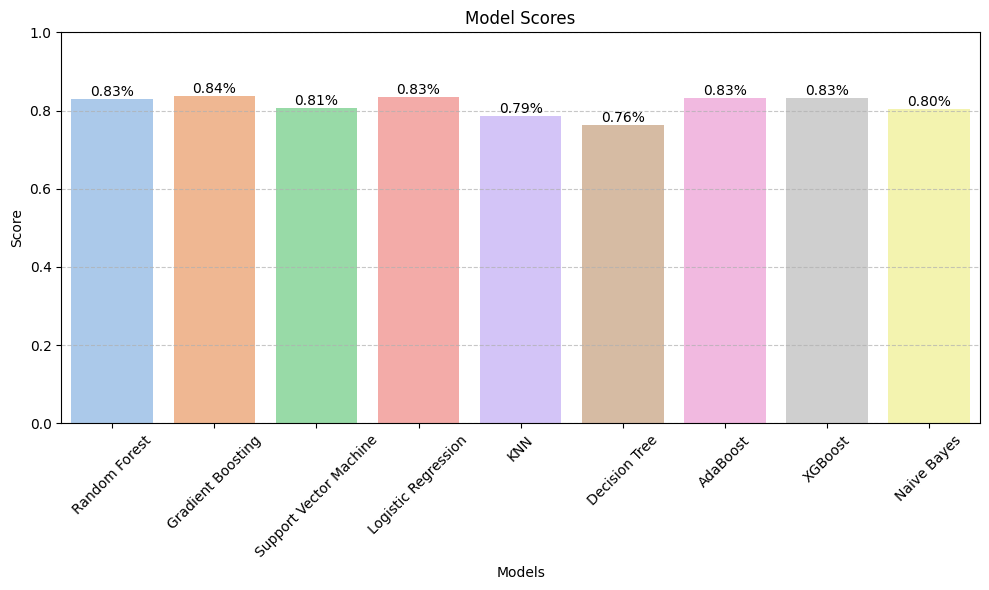

In [68]:
colors = sns.color_palette('pastel', n_colors=len(scores_df))


plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Model', y='ROC_AUC', data=scores_df, palette=colors)

for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=10, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.title('Model Scores')
plt.xlabel('Models')
plt.ylabel('Score')
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## 11. Feature Importance Analysis

<Axes: title={'center': 'Top 10 Feature Importances'}>

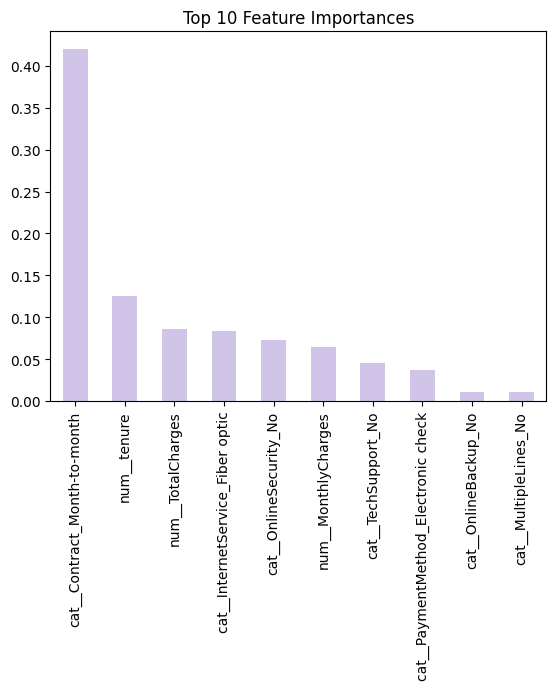

In [77]:
model = best_model.named_steps['model']
preprocessor = best_model.named_steps['preprocessor']

feature_names = preprocessor.get_feature_names_out()

importances = model.feature_importances_

feat_df = pd.Series(importances, index=feature_names)\
            .sort_values(ascending=False)[:10]

feat_df.plot(kind='bar', title='Top 10 Feature Importances',color='#d1c4e9')

## 12. Conclusion

Key insights from the project:

- Several machine learning models were compared using ROC-AUC.
- Tree-based models generally performed well for churn prediction. Gradient Boosting achieved the highest ROC-AUC of 0.84, outperforming Logistic Regression (0.78) and Random Forest (0.82).
- Feature importance analysis helped identify the most influential factors affecting customer churn.

This workflow demonstrates a full machine learning pipeline including preprocessing, model tuning, evaluation, and interpretation.

## Hypothesis Evaluation Summary

| Hypothesis | Result |
|------------|-------|
| Month-to-month contracts lead to higher churn | Supported |
| Senior citizens are more likely to churn | Partially supported |
| Customers with lower tenure churn more | Strongly supported |

Overall, contract flexibility and customer tenure appear to be the strongest indicators of churn risk.